# Input Parameters and Production System Description:

queue0 Event Log:
Time 0: Queue Sizes - Product 0: 1, Product 1: 0
Time 0: Queue Sizes - Product 0: 2, Product 1: 0
Time 0: Queue Sizes - Product 0: 3, Product 1: 0
Time 0: Queue Sizes - Product 0: 4, Product 1: 0
Time 0: Queue Sizes - Product 0: 5, Product 1: 0
Time 0: Queue Sizes - Product 0: 6, Product 1: 0
Time 0: Queue Sizes - Product 0: 7, Product 1: 0
Time 0: Queue Sizes - Product 0: 8, Product 1: 0
Time 0: Queue Sizes - Product 0: 9, Product 1: 0
Time 0: Queue Sizes - Product 0: 10, Product 1: 0
Time 0: Queue Sizes - Product 0: 11, Product 1: 0
Time 0: Queue Sizes - Product 0: 12, Product 1: 0
Time 0: Queue Sizes - Product 0: 13, Product 1: 0
Time 0: Queue Sizes - Product 0: 14, Product 1: 0
Time 0: Queue Sizes - Product 0: 15, Product 1: 0
Time 0: Queue Sizes - Product 0: 16, Product 1: 0
Time 0: Queue Sizes - Product 0: 17, Product 1: 0
Time 0: Queue Sizes - Product 0: 18, Product 1: 0
Time 0: Queue Sizes - Product 0: 19, Product 1: 0
Time 0: Queue Sizes - Product 0: 20, Prod

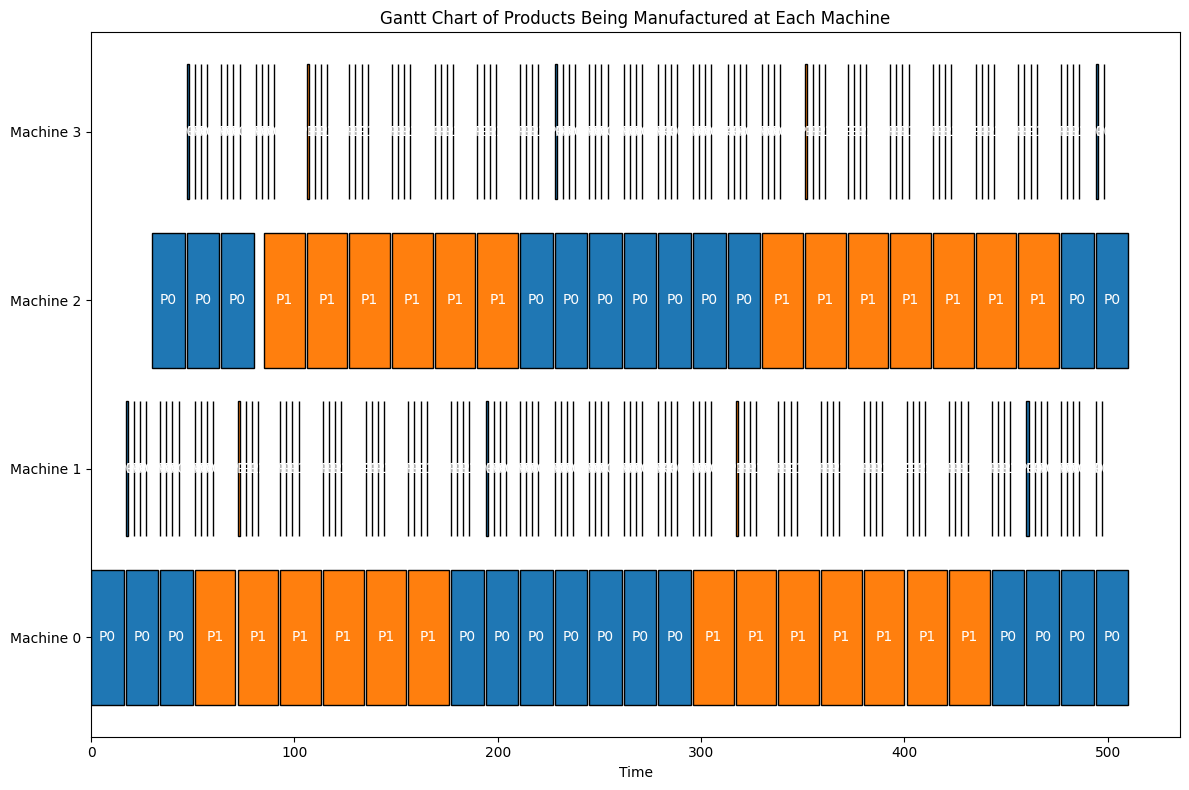

In [ ]:
import random
import pandas as pd
import matplotlib.pyplot as plt
import os
from typing import Optional, Dict, Any  # <-- add at top near your imports

def make_common_config(mode: str = "ALL_AT_T0", H: int = 100) -> Dict[str, Any]:
    # Base parameters (match both models)
    common = {
        'time_horizon': H,
        'machines': [0, 1, 2, 3],
        'products': [0, 1],

        # Processing/batch/setup identical to your code
        'processing_times': {
            0: {0: 16, 1: 20},
            1: {0: 2,  1: 2},
            2: {0: 16, 1: 20},
            3: {0: 2,  1: 2},
        },
        'batch_sizes': {0: 4, 1: 1, 2: 4, 3: 1},
        'setup_times': {     # informational for sim; MILP uses constraints
            0: {0: {0: 0, 1: 0}, 1: {0: 0, 1: 0}},
            1: {0: {0: 0, 1: 1}, 1: {0: 1, 1: 0}},
            2: {0: {0: 0, 1: 0}, 1: {0: 0, 1: 0}},
            3: {0: {0: 0, 1: 1}, 1: {0: 1, 1: 0}},
        },

        # Economics — match both
        'revenue_per_unit': {0: 50, 1: 60},
        'production_cost': {
            0: {0: 8,  1: 10},
            1: {0: 4,  1: 4},
            2: {0: 8,  1: 10},
            3: {0: 4,  1: 4},
        },
        'setup_cost': {0: 0, 1: 20, 2: 0, 3: 20},
        'inventory_cost_per_unit': {0: 0.5, 1: 0.6},
        'backorder_cost_per_unit': {0: 15, 1: 18},

        # Initial WIP (queues 1..3) and FG must be zero for fair comparison
        'initial_inventory': {
            0: {0: 0, 1: 0},   # queue0 starts empty; arrivals_schedule will feed it
            1: {0: 0, 1: 0},
            2: {0: 0, 1: 0},
            3: {0: 0, 1: 0},
            'finished': {0: 0, 1: 0},
        },

        # Schedules (length = H). Fill below by mode.
        'arrivals_schedule': {},   # raw material released to queue0 each period
        'demand_schedule': {},     # external demand each period
    }

    # Totals to match your previous cases (64 each)
    TOTAL_0, TOTAL_1 = 64, 64

    def zero(H): return [0]*H

    if mode.upper() == "ALL_AT_T0":
        arr0 = zero(H); arr1 = zero(H); dem0 = zero(H); dem1 = zero(H)
        arr0[0] = TOTAL_0; arr1[0] = TOTAL_1
        dem0[0] = TOTAL_0; dem1[0] = TOTAL_1
    elif mode.upper() == "UNIFORM":
        # spread evenly by integer division; remainder in earliest slots
        base0, r0 = divmod(TOTAL_0, H)
        base1, r1 = divmod(TOTAL_1, H)
        arr0 = [base0 + (1 if t < r0 else 0) for t in range(H)]
        arr1 = [base1 + (1 if t < r1 else 0) for t in range(H)]
        dem0 = arr0[:]  # choose whether you want demand to mirror arrivals or not
        dem1 = arr1[:]
    else:
        raise ValueError("mode must be ALL_AT_T0 or UNIFORM")

    common['arrivals_schedule'] = {0: arr0, 1: arr1}
    common['demand_schedule']   = {0: dem0, 1: dem1}
    common['demand'] = {0: TOTAL_0, 1: TOTAL_1}  # keep totals for reporting

    return common


# Simulation Parameters
#Total_Sim_Time = 2880 * 1
#672

# Machine Processing Times and Setups
Mac0_PT = [16, 20]
Mac1_PT = [2, 2]
Mac2_PT = [16, 20]
Mac3_PT = [2, 2]
Mac1_setups = {None: {0: 1, 1: 1}, 0: {0: 0, 1: 1}, 1: {0: 1, 1: 0}}
Mac3_setups = {None: {0: 1, 1: 1}, 0: {0: 0, 1: 1}, 1: {0: 1, 1: 0}}

# Product ID Mapping
product_id_mapping = {'Product 1': 0, 'Product 2': 1}

# --- BEGIN: Removed DF-based event generation (now driven by shared config) ---
# Event Generation Functions
# def generate_events_fixed(...): ...
# def generate_events_random(...): ...
# def simulate_events(...): ...
# product_settings = {...}
# arrivals_df, demands_df = simulate_events(...)
# print("Arrivals DataFrame:"); print(arrivals_df)
# print("\nDemands DataFrame:"); print(demands_df)
# --- END REMOVED ---

# Graft in common config for perfect MILP↔Sim alignment
common = make_common_config(mode="ALL_AT_T0", H=500)  # <<< CHANGED (single source of truth)
# If you prefer UNIFORM timing: common = make_common_config(mode="UNIFORM", H=50)

# Machine Classes
class BatchProcessingMachine:
    def __init__(self, processing_times, batch_size):
        self.processing_times = processing_times
        self.batch_size = batch_size
        self.current_product = None
        self.finish_time = 0
        self.busy = False
        self.event_log = []

    def process(self, product, current_time):
        self.busy = True
        self.finish_time = current_time + self.processing_times[product]
        self.current_product = product
        self.event_log.append((self.current_product, current_time, self.finish_time, self.batch_size))
        return self.finish_time

    def update(self, current_time):
        if current_time >= self.finish_time and self.busy:
            self.busy = False
            return self.current_product
        return False
    
    def print_event_log(self, machine_name):
        for event in self.event_log:
            print(f"At machine {machine_name}: Batch of Product {event[0]} processed from {event[1]} to {event[2]}")

class Machine:
    def __init__(self, processing_times, setup_times):
        self.processing_times = processing_times
        self.setup_times = setup_times
        self.current_product = None
        self.finish_time = 0
        self.busy = False
        self.event_log = []

    def process(self, product, current_time):
        if self.current_product is not None:
            setup_time = self.setup_times[self.current_product][product]
        else:
            setup_time = self.setup_times[None][product]
        self.current_product = product
        start_time = current_time + setup_time
        self.finish_time = start_time + self.processing_times[product]
        self.busy = True
        self.event_log.append((product, current_time, start_time, self.finish_time))
        return self.finish_time

    def update(self, current_time):
        if current_time >= self.finish_time and self.busy:
            self.busy = False
            return self.current_product
        return None

    def print_event_log(self, machine_name):
        for event in self.event_log:
            print(f"At machine {machine_name}: Product {event[0]} processed from {event[1]} to {event[3]}")

# Commander Class
class Commander:
    def __init__(self, machine0, machine1, machine2, machine3):
        self.machine0 = machine0
        self.machine1 = machine1
        self.machine2 = machine2
        self.machine3 = machine3

    def decide_actions(self, state):

        actions: Dict[str, Optional[str]] = {'machine0': None, 'machine1': None, 'machine2': None, 'machine3': None}
        queue0_product_0 = state['Queue 0 Product 0']
        queue0_product_1 = state['Queue 0 Product 1']
        queue1_product_0 = state['Queue 1 Product 0']
        queue1_product_1 = state['Queue 1 Product 1']
        queue2_product_0 = state['Queue 2 Product 0']
        queue2_product_1 = state['Queue 2 Product 1']
        queue3_product_0 = state['Queue 3 Product 0']
        queue3_product_1 = state['Queue 3 Product 1']
        Demand_product_0 = state['Demand Queue Product 0']
        Demand_product_1 = state['Demand Queue Product 1']

        demandremainpct0 = 0 if (Demand_product_0 +  Demand_product_1) == 0 else (Demand_product_0 / (Demand_product_0 +  Demand_product_1))
        demandremainpct1 = 0 if (Demand_product_0 +  Demand_product_1) == 0 else (Demand_product_1 / (Demand_product_0 +  Demand_product_1))

        avgdemrempct = (demandremainpct0  + demandremainpct1) / 2

        # Decisions for Machine 0:
        if self.machine0.busy == False and queue0_product_0 >= self.machine0.batch_size and queue0_product_1 >= self.machine0.batch_size:
            actions['machine0'] = 'Prod0' if demandremainpct0 >= avgdemrempct else 'Prod1' 
            #actions['machine0_Comment'] = 'Machine0 is not busy and both available, decided to make based on demand remaining'
        elif self.machine0.busy == False and queue0_product_0 >= self.machine0.batch_size and queue0_product_1 < self.machine0.batch_size:
            actions['machine0'] = 'Prod0'
            #actions['machine0_Comment'] = 'Machine0 is not busy and only 0 is avaible'
        elif self.machine0.busy == False and queue0_product_0 < self.machine0.batch_size and queue0_product_1 >= self.machine0.batch_size:
            actions['machine0'] = 'Prod1'
            #actions['machine0_Comment'] = 'Machine0 is not busy and only 1 is avaible'
        else:
            actions['machine0'] = None
            #actions['machine0_Comment'] = 'Machine0 is busy making none'
        
        # Decisions for Machine 1
        if self.machine1.busy == False and queue1_product_0  > 0  and queue1_product_1 > 0:
            actions['machine1'] = 'Prod0' if demandremainpct0 >= avgdemrempct else 'Prod1' 
            #actions['machine1_Comment'] = 'Machine1 is not busy and both available, decided to make based on demand remaining'
        elif self.machine1.busy == False and queue1_product_0  > 0 and queue1_product_1 == 0:
            actions['machine1'] = 'Prod0'
            #actions['machine1_Comment'] = 'Machine1 is not busy and only 0 is available, decided to make Prod 0'
        elif self.machine1.busy == False and queue1_product_0  == 0 and queue1_product_1 > 0:
            actions['machine1'] = 'Prod1'
            #actions['machine1_Comment'] = 'Machine1 is not busy and only 1 is available, decided to make Prod 1'
        else:
            actions['machine1'] = None
            actions['machine1_Comment'] = 'Machine1 is busy making none'

        # Decisions for Machine 2
        if self.machine2.busy == False and queue2_product_0 >= self.machine2.batch_size and queue2_product_1 >= self.machine2.batch_size:
            actions['machine2'] = 'Prod0' if demandremainpct0 >= avgdemrempct else 'Prod1' 
        elif self.machine2.busy == False and queue2_product_0 >= self.machine2.batch_size and queue2_product_1 < self.machine2.batch_size:
            actions['machine2'] = 'Prod0'
        elif self.machine2.busy == False and queue2_product_0 < self.machine2.batch_size and queue2_product_1 >= self.machine2.batch_size:
            actions['machine2'] = 'Prod1'
        else:
            actions['machine2'] = None
        # Decisions for Machine 3
        if self.machine3.busy == False and queue3_product_0 > 0  and queue3_product_1 > 0:
            actions['machine3'] = 'Prod0' if demandremainpct0 >= avgdemrempct else 'Prod1' 
        elif self.machine3.busy == False and queue3_product_0 > 0 and queue3_product_1 <= 0:
            actions['machine3'] = 'Prod0'
        elif self.machine3.busy == False and queue3_product_0 <= 0 and queue3_product_1 > 0:
            actions['machine3'] = 'Prod1'
        else:
            actions['machine3'] = None

        return actions

# Production Line Class
class ProductionLine:
    def __init__(self, batch_machine0_times, machine1_times, machine1_setups, batch_machine2_times, machine3_times, machine3_setups, common_cfg):  # <<< CHANGED (take common_cfg, drop DFs)
        self.machine0 = BatchProcessingMachine(batch_machine0_times, 4)
        self.machine1 = Machine(machine1_times, machine1_setups)
        self.machine2 = BatchProcessingMachine(batch_machine2_times, 4)
        self.machine3 = Machine(machine3_times, machine3_setups)

        # <<< CHANGED: schedules & horizon from common config
        self.arrivals_schedule = common_cfg['arrivals_schedule']   # dict: {product: [len H]}
        self.demand_schedule   = common_cfg['demand_schedule']     # dict: {product: [len H]}
        self.H = common_cfg['time_horizon']

        self.queues = {'queue0': [[], []], 'queue1': [[], []], 'queue2': [[], []], 'queue3': [[], []], 'queue_fin': [[], []], 'demand': [[], []]}
        self.logs = {key: [] for key in self.queues}
        self.demand_met_log = []
        self.event_log = []

        # <<< CHANGED: total demand computed from schedule
        self.total_demand = {
            0: sum(self.demand_schedule[0]),
            1: sum(self.demand_schedule[1])
        }

        self.commander = Commander(self.machine0, self.machine1, self.machine2, self.machine3)

        # === Economics (match MILP/common config) and cost/revenue trackers ===
        self.econ = {  # <<< CHANGED: pull from common config
            'revenue_per_unit': common_cfg['revenue_per_unit'],
            'production_cost':  common_cfg['production_cost'],
            'setup_cost':       common_cfg['setup_cost'],
            'inventory_cost_per_unit': common_cfg['inventory_cost_per_unit'],
            'backorder_cost_per_unit': common_cfg['backorder_cost_per_unit']
        }
        self.costs = {'revenue': 0.0, 'production': 0.0, 'setup': 0.0, 'inventory': 0.0, 'backorder': 0.0}
        self.cost_log = []  # optional: running log per time step

    def add_item_to_queue(self, queue_name, product_name, current_time):
        if queue_name == 'queue_fin':
            if len(self.queues['demand'][product_name]) > 0:
                self.queues['demand'][product_name].pop(0)
                self.demand_met_log.append((product_name, current_time))
                queue_sizes = [len(q) for q in self.queues['demand']]
                self.logs['demand'].append((queue_sizes, current_time))
                #self.log_current_state(current_time,action)
                self.costs['revenue'] += self.econ['revenue_per_unit'][product_name]
                return
        self.queues[queue_name][product_name].append(current_time)
        queue_sizes = [len(q) for q in self.queues[queue_name]]
        self.logs[queue_name].append((queue_sizes, current_time))

    def log_current_state(self, current_time, actions):
        log_entry = {
            'Time': current_time,
            'Machine 0 Action': actions['machine0'],
            'Machine 1 Action': actions['machine1'],
            'Machine 2 Action': actions['machine2'],
            'Machine 3 Action': actions['machine3'],
            'Queue 0 Product 0': len(self.queues['queue0'][0]),
            'Queue 0 Product 1': len(self.queues['queue0'][1]),
            'Queue 1 Product 0': len(self.queues['queue1'][0]),
            'Queue 1 Product 1': len(self.queues['queue1'][1]),
            'Queue 2 Product 0': len(self.queues['queue2'][0]),
            'Queue 2 Product 1': len(self.queues['queue2'][1]),
            'Queue 3 Product 0': len(self.queues['queue3'][0]),
            'Queue 3 Product 1': len(self.queues['queue3'][1]),
            'Queue Fin Product 0': len(self.queues['queue_fin'][0]),
            'Queue Fin Product 1': len(self.queues['queue_fin'][1]),
            'Demand Queue Product 0': len(self.queues['demand'][0]),
            'Demand Queue Product 1': len(self.queues['demand'][1]),
            'Machine 0 Current Product': 'None' if self.machine0.current_product is None else self.machine0.current_product,
            'Machine 1 Current Product': 'None' if self.machine1.current_product is None else self.machine1.current_product,
            'Machine 2 Current Product': 'None' if self.machine2.current_product is None else self.machine2.current_product,
            'Machine 3 Current Product': 'None' if self.machine3.current_product is None else self.machine3.current_product,
            'Machine 0 timeremaining': 'None' if self.machine0.current_product is None else max(self.machine0.finish_time - current_time, 0),
            'Machine 1 timeremaining': 'None' if self.machine1.current_product is None else max(self.machine1.finish_time - current_time, 0),
            'Machine 2 timeremaining': 'None' if self.machine2.current_product is None else max(self.machine2.finish_time - current_time, 0),
            'Machine 3 timeremaining': 'None' if self.machine3.current_product is None else max(self.machine3.finish_time - current_time, 0),
        }
        self.event_log.append(log_entry)

    def remove_item_from_queue(self, queue_name, product_name, current_time):
        if self.queues[queue_name][product_name]:
            self.queues[queue_name][product_name].pop(0)
            queue_sizes = [len(q) for q in self.queues[queue_name]]
            self.logs[queue_name].append((queue_sizes, current_time))

    def run_step(self, current_time, totaltime):
        # <<< CHANGED: arrivals from common schedule
        if current_time < self.H:
            for j in (0, 1):
                qty = self.arrivals_schedule[j][current_time]
                for _ in range(qty):
                    self.add_item_to_queue('queue0', j, current_time)

            # Demand arrivals from common schedule
            for j in (0, 1):
                qty = self.demand_schedule[j][current_time]
                for _ in range(qty):
                    self.add_item_to_queue('demand', j, current_time)

        # --- rest is unchanged (policy and processing logic) ---
        state = {
            'Time': current_time,
            'Queue 0 Product 0': len(self.queues['queue0'][0]),
            'Queue 0 Product 1': len(self.queues['queue0'][1]),
            'Queue 1 Product 0': len(self.queues['queue1'][0]),
            'Queue 1 Product 1': len(self.queues['queue1'][1]),
            'Queue 2 Product 0': len(self.queues['queue2'][0]),
            'Queue 2 Product 1': len(self.queues['queue2'][1]),
            'Queue 3 Product 0': len(self.queues['queue3'][0]),
            'Queue 3 Product 1': len(self.queues['queue3'][1]),
            'Queue Fin Product 0': len(self.queues['queue_fin'][0]),
            'Queue Fin Product 1': len(self.queues['queue_fin'][1]),
            'Demand Queue Product 0': len(self.queues['demand'][0]),
            'Demand Queue Product 1': len(self.queues['demand'][1]),
            'Machine 0 Current Product': 'None' if self.machine0.current_product is None else self.machine0.current_product,
            'Machine 1 Current Product': 'None' if self.machine1.current_product is None else self.machine1.current_product,
            'Machine 2 Current Product': 'None' if self.machine2.current_product is None else self.machine2.current_product,
            'Machine 3 Current Product': 'None' if self.machine3.current_product is None else self.machine3.current_product,
            'Machine 0 timeremaining': 'None' if self.machine0.current_product is None else max(self.machine0.finish_time - current_time, 0),
            'Machine 1 timeremaining': 'None' if self.machine1.current_product is None else max(self.machine1.finish_time - current_time, 0),
            'Machine 2 timeremaining': 'None' if self.machine2.current_product is None else max(self.machine2.finish_time - current_time, 0),
            'Machine 3 timeremaining': 'None' if self.machine3.current_product is None else max(self.machine3.finish_time - current_time, 0),
        }
        actions = self.commander.decide_actions(state)

        for product_type in range(2):
            if current_time >= self.machine0.finish_time and self.machine0.busy:
                finished_product = self.machine0.update(current_time)
                for _ in range(self.machine0.batch_size):
                    self.add_item_to_queue('queue1', finished_product, current_time)
            if actions['machine0'] == 'Prod' + str(product_type):
                for _ in range(self.machine0.batch_size):
                    self.remove_item_from_queue('queue0', product_type, current_time)
                self.costs['production'] += self.econ['production_cost'][0][product_type]
                self.machine0.process(product_type, current_time)

        for product_type in range(2):
            if current_time >= self.machine1.finish_time and self.machine1.busy:
                finished_product1 = self.machine1.update(current_time)
                if finished_product1 is not None:
                    self.add_item_to_queue('queue2', finished_product1, current_time)
            if actions['machine1'] == 'Prod' + str(product_type):
                self.remove_item_from_queue('queue1', product_type, current_time)
                prev = self.machine1.current_product
                self.machine1.process(product_type, current_time)
                if prev is not None and prev != product_type:
                    self.costs['setup'] += self.econ['setup_cost'][1]
                self.costs['production'] += self.econ['production_cost'][1][product_type]

        for product_type in range(2):
            if current_time >= self.machine2.finish_time and self.machine2.busy:
                finished_product2 = self.machine2.update(current_time)
                for _ in range(self.machine2.batch_size):
                    self.add_item_to_queue('queue3', finished_product2, current_time)
            if actions['machine2'] == 'Prod' + str(product_type):
                for _ in range(self.machine2.batch_size):
                    self.remove_item_from_queue('queue2', product_type, current_time)
                self.costs['production'] += self.econ['production_cost'][2][product_type]
                self.machine2.process(product_type, current_time)

        for product_type in range(2):
            if current_time >= self.machine3.finish_time and self.machine3.busy:
                finished_product3 = self.machine3.update(current_time)
                if finished_product3 is not None:
                    self.add_item_to_queue('queue_fin', finished_product3, current_time)
            if actions['machine3'] == 'Prod' + str(product_type):
                self.remove_item_from_queue('queue3', product_type, current_time)
                prev3 = self.machine3.current_product
                self.machine3.process(product_type, current_time)
                if prev3 is not None and prev3 != product_type:
                    self.costs['setup'] += self.econ['setup_cost'][3]
                self.costs['production'] += self.econ['production_cost'][3][product_type]

        self.log_current_state(current_time,actions)

        # === per-period inventory & backorder costs (end of step) ===
        for j in range(2):
            inv_units = (
                len(self.queues['queue0'][j]) +
                len(self.queues['queue1'][j]) +
                len(self.queues['queue2'][j]) +
                len(self.queues['queue3'][j]) +
                len(self.queues['queue_fin'][j])
            )
            self.costs['inventory'] += self.econ['inventory_cost_per_unit'][j] * inv_units
            self.costs['backorder'] += self.econ['backorder_cost_per_unit'][j] * len(self.queues['demand'][j])

        self.cost_log.append({
            'Time': current_time,
            'revenue': self.costs['revenue'],
            'production': self.costs['production'],
            'setup': self.costs['setup'],
            'inventory': self.costs['inventory'],
            'backorder': self.costs['backorder'],
            'profit': self.costs['revenue'] - (self.costs['production'] + self.costs['setup'] + self.costs['inventory'] + self.costs['backorder'])
        })

    def print_demand_met_log(self):
        print("Demand Met Log:")
        for log in self.demand_met_log:
            print(f"Time {log[1]}: Demand for Product {log[0]} met")
    
    def print_logs(self):
        for key in self.queues:
            print(f"{key} Event Log:")
            for log in self.logs[key]:
                print(f"Time {log[1]}: Queue Sizes - Product 0: {log[0][0]}, Product 1: {log[0][1]}")

        print("\nMachine Logs:")
        machine_names = ['Machine 0', 'Machine 1', 'Machine 2', 'Machine 3']
        for i in range(4):
            machine = getattr(self, f'machine{i}')
            machine.print_event_log(machine_names[i])

        self.print_demand_met_log()

# Gantt Chart Functions
def extract_gantt_data(production_line):
    gantt_data = []
    for machine_name in ['machine0', 'machine1', 'machine2', 'machine3']:
        machine = getattr(production_line, machine_name)
        for event in machine.event_log:
            start_time = event[1]
            end_time = event[2]
            product = event[0]
            gantt_data.append({
                'Machine': machine_name,
                'Start': start_time,
                'Finish': end_time,
                'Product': product
            })
    return pd.DataFrame(gantt_data)

def plot_gantt_chart(gantt_df):
    fig, ax = plt.subplots(figsize=(12, 8))
    
    machine_names = {
        'machine0': 'Machine 0',
        'machine1': 'Machine 1',
        'machine2': 'Machine 2',
        'machine3': 'Machine 3'
    }
    gantt_df['Machine'] = gantt_df['Machine'].map(machine_names)
    
    colors = {0: 'tab:blue', 1: 'tab:orange'}
    
    for i, row in gantt_df.iterrows():
        ax.barh(row['Machine'], row['Finish'] - row['Start'], left=row['Start'], color=colors[row['Product']], edgecolor='black')
        ax.text((row['Start'] + row['Finish']) / 2, row['Machine'], f'P{row["Product"]}', va='center', ha='center', color='white')
    
    ax.set_xlabel('Time')
    ax.set_title('Gantt Chart of Products Being Manufactured at Each Machine')
    ax.set_yticks(range(len(machine_names)))
    ax.set_yticklabels(machine_names.values())
    plt.tight_layout()
    plt.show()

# Run Simulation
production_line = ProductionLine(
    {0: Mac0_PT[0], 1: Mac0_PT[1]}, 
    {0: Mac1_PT[0], 1: Mac1_PT[1]}, 
    Mac1_setups,    
    {0: Mac2_PT[0], 1: Mac2_PT[1]}, 
    {0: Mac3_PT[0], 1: Mac3_PT[1]}, 
    Mac3_setups, 
    common_cfg=common  # <<< CHANGED (pass common; no arrivals_df/demands_df)
)

totaltime = common['time_horizon']  # <<< CHANGED (drive horizon from common)
for current_time in range(totaltime):
    production_line.run_step(current_time, totaltime)
production_line.print_logs()

# === print MILP-aligned totals from the simulation ===
totals = production_line.costs
profit = totals['revenue'] - (totals['production'] + totals['setup'] + totals['inventory'] + totals['backorder'])
print("\n=== ECONOMIC SUMMARY (Simulation) ===")
print(f"Revenue:            {totals['revenue']:.2f}")
print(f"Production costs:   {totals['production']:.2f}")
print(f"Setup costs:        {totals['setup']:.2f}")
print(f"Inventory costs:    {totals['inventory']:.2f}")
print(f"Backorder costs:    {totals['backorder']:.2f}")
print(f"-------------------------------")
print(f"Total Profit:       {profit:.2f}")

# Create Gantt Chart Data and Plot
gantt_df = extract_gantt_data(production_line)
plot_gantt_chart(gantt_df)

# Save Event Log to CSV
event_log_df = pd.DataFrame(production_line.event_log)
current_directory = os.getcwd()
new_folder = "output_data"
new_folder_path = os.path.join(current_directory, new_folder)

if not os.path.exists(new_folder_path):
    os.makedirs(new_folder_path)

file_name = "final_event_log_Exp2.csv"
file_path = os.path.join(new_folder_path, file_name)
event_log_df.to_csv(file_path, index=False)


# Generate demand and arrivals:

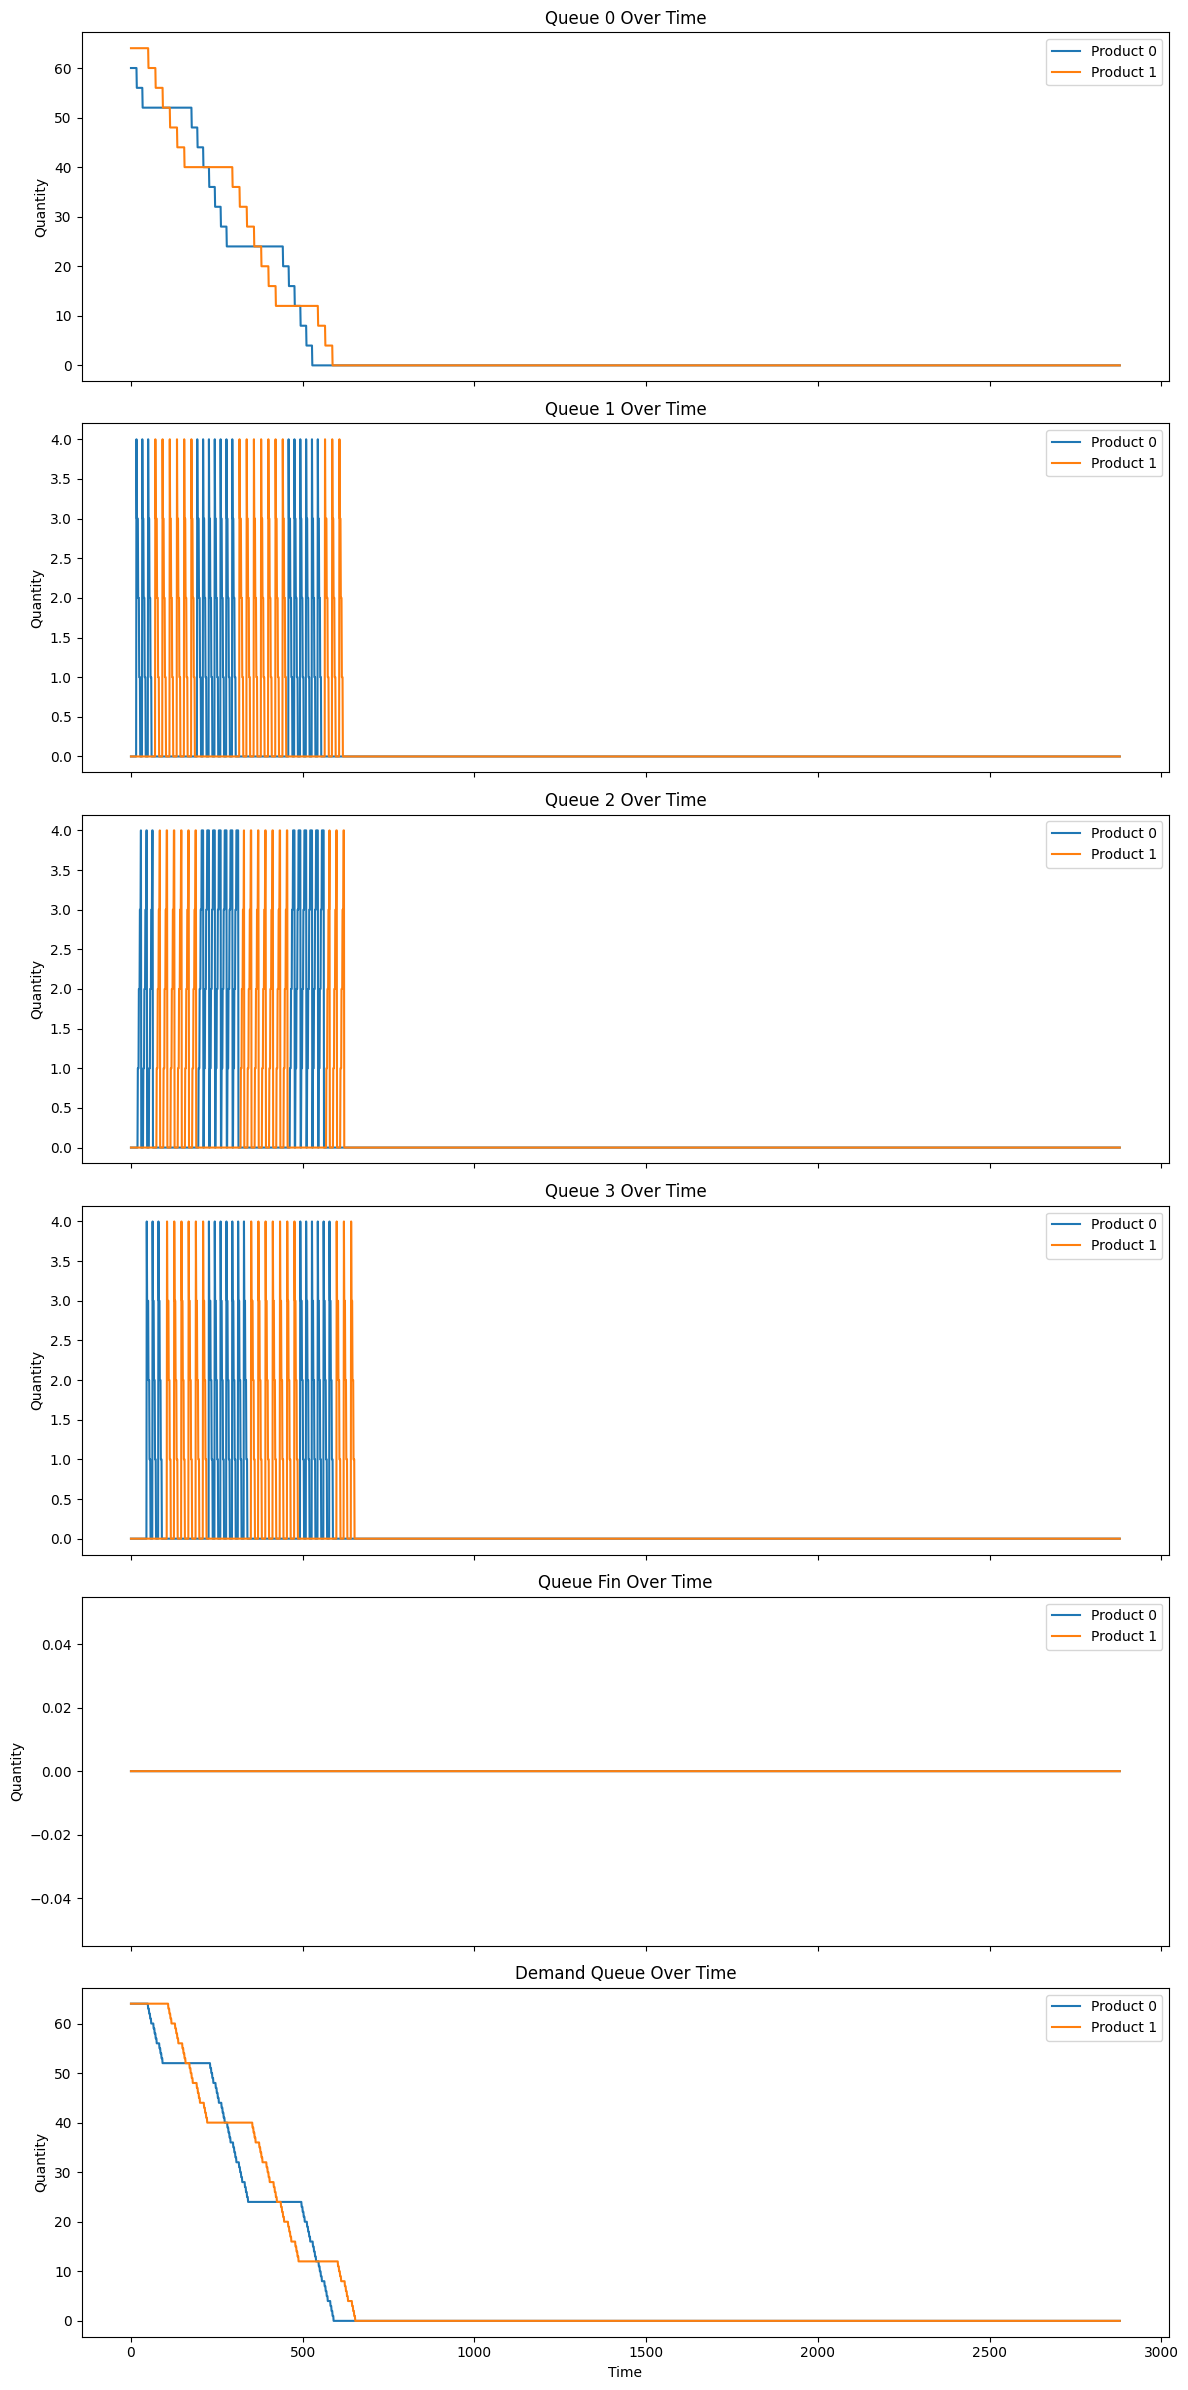

In [15]:
# Plot the number of Product 0 and Product 1 in each queue over time
fig, axs = plt.subplots(6, 1, figsize=(12, 24), sharex=True)
queues = ['Queue 0', 'Queue 1', 'Queue 2', 'Queue 3', 'Queue Fin', 'Demand Queue']

for i, queue in enumerate(queues):
    for product in [0, 1]:
        axs[i].plot(event_log_df['Time'], event_log_df[f'{queue} Product {product}'], label=f'Product {product}')
    axs[i].set_title(f'{queue} Over Time')
    axs[i].set_ylabel('Quantity')
    axs[i].legend()

axs[-1].set_xlabel('Time')
plt.tight_layout()
plt.show()

# Machine Class Initialization